## Data Understanding and Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [3]:
deliveries_df = pd.read_csv("dataset/amazon_deliveries.csv")
agents_df = pd.read_json("dataset/amazon_agents.json")

df = pd.merge(deliveries_df, agents_df, on='agent_id', how='left')

df.head(10)

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date
0,AMZ-20250425-00000,2025-04-25 19:13:00,Lucknow,D,8.31,3.11,Clear,9.44,Cycle,13.82,23.74,1,AGENT_05773,Agent_5773,7.28,Cycle,Chennai,2019-02-01
1,AMZ-20250110-00001,2025-01-10 02:58:00,Surat,C,11.62,4.63,Storm,7.22,Scooter,2.66,160.30,0,AGENT_04867,Agent_4867,9.92,Scooter,Ahmedabad,2018-02-05
2,AMZ-20250107-00002,2025-01-07 04:36:00,Chandigarh,C,1.71,3.77,Clear,7.30,Bike,1.38,14.25,0,AGENT_00817,Agent_817,3.81,Cycle,Bangalore,2023-01-14
3,AMZ-20250116-00003,2025-01-16 04:05:00,Hyderabad,D,5.73,3.77,Clear,8.91,Van,3.09,132.63,1,AGENT_05587,Agent_5587,NaN,Van,Pune,2023-05-12
4,AMZ-20250312-00004,2025-03-12 19:51:00,Delhi,B,5.07,3.17,Fog,1.50,Van,3.73,83.14,1,AGENT_05724,Agent_5724,3.23,Cycle,Bangalore,2018-12-11
5,AMZ-20250116-00005,2025-01-16 03:19:00,Kolkata,A,21.28,3.17,Fog,8.44,Van,0.85,12.00,0,AGENT_00087,Agent_87,8.64,Van,Jaipur,2020-04-16
6,AMZ-20250129-00006,2025-01-29 17:54:00,Nagpur,A,1.82,4.02,Rain,7.75,Van,2.36,22.22,1,AGENT_03606,Agent_3606,6.25,Cycle,Nagpur,2024-06-03
7,AMZ-20250426-00007,2025-04-26 08:44:00,Chandigarh,A,4.12,3.48,Clear,1.59,Scooter,1.04,19.88,0,AGENT_03799,Agent_3799,7.34,Bike,Lucknow,2020-02-08
8,AMZ-20250419-00008,2025-04-19 07:25:00,Delhi,C,3.86,3.76,Clear,2.29,Bike,0.80,94.89,0,AGENT_00080,Agent_80,3.78,Bike,Chandigarh,2018-08-23
9,AMZ-20250313-00009,2025-03-13 11:36:00,Lucknow,B,12.96,4.24,NaN,3.44,Bike,9.50,91.37,0,AGENT_02273,Agent_2273,4.95,Van,Lucknow,2019-01-05


In [4]:
print("Merged DataFrame shape have {} rows and {} columns".format(df.shape[0], df.shape[1]))

Merged DataFrame shape have 50000 rows and 18 columns


In [5]:
df.dtypes

order_id              object
order_datetime        object
delivery_city         object
delivery_zone         object
distance_km          float64
agent_rating         float64
weather_condition     object
traffic_index        float64
vehicle_type          object
package_weight_kg    float64
delivery_time_min    float64
is_delayed             int64
agent_id              object
agent_name            object
experience_years     float64
vehicle_owned         object
city_assigned         object
joining_date          object
dtype: object

In [6]:
df["delivery_city"].value_counts()

delivery_city
Nagpur        3278
Delhi         3178
Bangalore     3177
Jaipur        3161
Indore        3155
Chennai       3148
Pune          3131
Mumbai        3128
Surat         3123
Hyderabad     3117
Kolkata       3115
Chandigarh    3098
Bhopal        3091
Ahmedabad     3090
Patna         3010
Lucknow       3000
Name: count, dtype: int64

In [7]:
df["vehicle_type"].value_counts()

vehicle_type
Van        12624
Bike       12505
Scooter    12494
Cycle      12377
Name: count, dtype: int64

In [8]:
df["weather_condition"].value_counts()

weather_condition
Fog       9712
Cloudy    9685
Clear     9659
Rain      9619
Storm     9349
Name: count, dtype: int64

In [9]:
df["delivery_zone"].value_counts()

delivery_zone
C    12619
D    12617
A    12437
B    12327
Name: count, dtype: int64

In [10]:
df.describe(include=['float64', 'int64'])

,distance_km,agent_rating,traffic_index,package_weight_kg,delivery_time_min,is_delayed,experience_years
count,48528.000000,48940.000000,47463.000000,50000.000000,50000.000000,50000.00000,49466.000000
mean,8.089187,4.000503,5.001465,3.007288,49.806179,0.50216,5.027537
std,8.069656,0.499063,2.875610,3.015805,39.782517,0.50000,2.875428
min,0.000000,1.910000,0.000000,0.000000,10.000000,0.00000,0.000000
25%,2.350000,3.660000,2.530000,0.850000,21.400000,0.00000,2.520000
50%,5.610000,4.000000,4.980000,2.090000,37.540000,1.00000,5.035000
75%,11.222500,4.340000,7.480000,4.180000,65.170000,1.00000,7.550000
max,87.560000,6.010000,10.000000,36.580000,410.680000,1.00000,10.000000


In [11]:
df.isnull().sum()

order_id                0
order_datetime          0
delivery_city           0
delivery_zone           0
distance_km          1472
agent_rating         1060
weather_condition    1976
traffic_index        2537
vehicle_type            0
package_weight_kg       0
delivery_time_min       0
is_delayed              0
agent_id                0
agent_name              0
experience_years      534
vehicle_owned           0
city_assigned           0
joining_date            0
dtype: int64

In [12]:
print(f"Missing value % in distance_km column is: {df['distance_km'].isnull().sum() / len(df) * 100:.2f}%")
print(f"Missing value % in agent_rating column is: {df['agent_rating'].isnull().sum() / len(df) * 100:.2f}%")
print(f"Missing value % in weather_condition column is: {df['weather_condition'].isnull().sum() / len(df) * 100:.2f}%")
print(f"Missing value % in traffic_index column is: {df['traffic_index'].isnull().sum() / len(df) * 100:.2f}%")
print(f"Missing value % in experience_years column is: {df['experience_years'].isnull().sum() / len(df) * 100:.2f}%")

Missing value % in distance_km column is: 2.94%
Missing value % in agent_rating column is: 2.12%
Missing value % in weather_condition column is: 3.95%
Missing value % in traffic_index column is: 5.07%
Missing value % in experience_years column is: 1.07%


In [13]:
print(f"column distance and traffic_index have more then 5% of missing values,{5.07} and {5.07} respectively, so we will treat this column with advance imputation techiques like KNN imputer or Iterative imputer. For other columns we will treat them with simple imputation techniques like mean, median or mode.")

column distance and traffic_index have more then 5% of missing values,5.07 and 5.07 respectively, so we will treat this column with advance imputation techiques like KNN imputer or Iterative imputer. For other columns we will treat them with simple imputation techniques like mean, median or mode.


In [14]:
#sns.barplot(data=df, x=df.columns[df.isnull().any()], y=df.isnull().sum())

## Data Cleaning

In [15]:
median_imputer = SimpleImputer(strategy='median')
df['median_distance_km'] = median_imputer.fit_transform(df[['distance_km']])

df['median_distance_km'].isnull().sum()

np.int64(0)

In [16]:
mean_imputer = SimpleImputer(strategy='mean')
df['mean_agent_rating'] = mean_imputer.fit_transform(df[['agent_rating']])

df['mean_agent_rating'].isnull().sum()

np.int64(0)

In [17]:
mode_imputer = SimpleImputer(strategy='most_frequent')

df['mode_weather_condition'] = mode_imputer.fit_transform(
    df[['weather_condition']]
).ravel()

df['mode_weather_condition'].isnull().sum()

np.int64(0)

In [18]:
median_imputer = SimpleImputer(strategy='median')
df['median_traffic_index'] = median_imputer.fit_transform(df[['traffic_index']])
df['median_traffic_index'].isnull().sum()

np.int64(0)

In [19]:
df['order_datetime'] = pd.to_datetime(df['order_datetime'])

df['order_datetime'].dtypes

dtype('<M8[ns]')

In [20]:
df[df.duplicated('order_id', keep=False)]

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date,median_distance_km,mean_agent_rating,mode_weather_condition,median_traffic_index


In [21]:
df[df.duplicated(['order_datetime', 'delivery_city', 'agent_id'], keep=False)]

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date,median_distance_km,mean_agent_rating,mode_weather_condition,median_traffic_index


In [22]:
original_count = len(df)
df = df.drop_duplicates('order_id').reset_index(drop=True)

In [23]:
print("Records removed:", original_count - len(df))

Records removed: 0


In [24]:
df['delivery_city'].value_counts()

delivery_city
Nagpur        3278
Delhi         3178
Bangalore     3177
Jaipur        3161
Indore        3155
Chennai       3148
Pune          3131
Mumbai        3128
Surat         3123
Hyderabad     3117
Kolkata       3115
Chandigarh    3098
Bhopal        3091
Ahmedabad     3090
Patna         3010
Lucknow       3000
Name: count, dtype: int64

In [25]:
df['vehicle_type'].value_counts()

vehicle_type
Van        12624
Bike       12505
Scooter    12494
Cycle      12377
Name: count, dtype: int64

<Axes: xlabel='delhivery_winzorised_distance_km'>

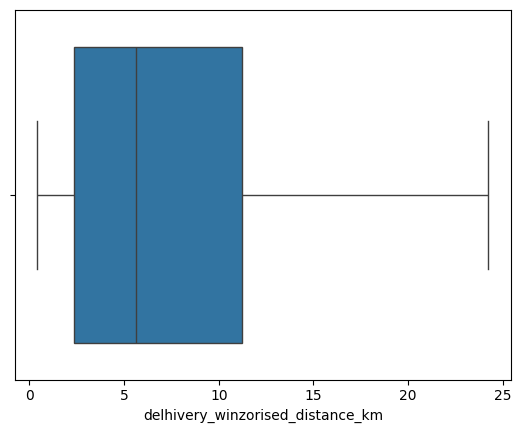

In [27]:
lower = df['distance_km'].quantile(0.05)
upper = df['distance_km'].quantile(0.95)

df['delhivery_winzorised_distance_km'] = df['distance_km'].clip(lower, upper)

sns.boxplot(data=df, x='delhivery_winzorised_distance_km')

In [35]:
df['delivery_time_min'] = pd.to_datetime(df['delivery_time_min'])

In [37]:
# df['delivery_time_error'] = df['delivery_time_min'] < 5

## Exploratory Data Analysis 

<Axes: xlabel='delhivery_winzorised_distance_km'>

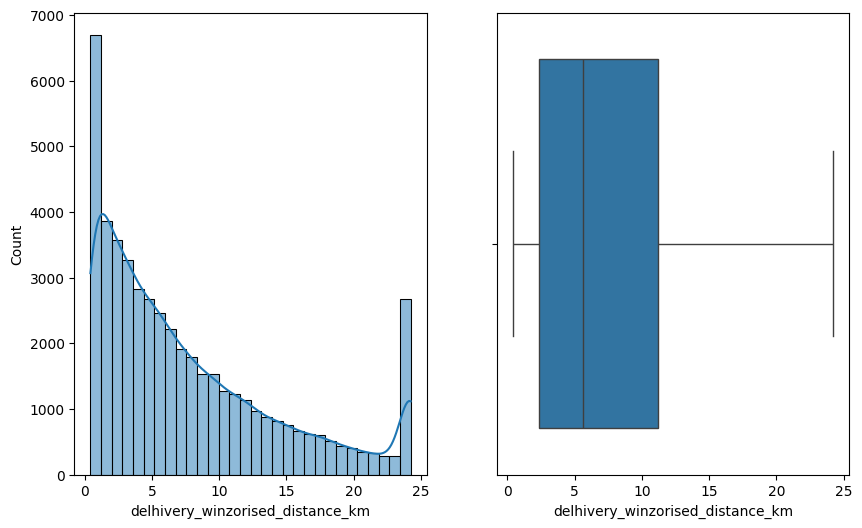

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 6))

sns.histplot(data=df, x='delhivery_winzorised_distance_km', bins=30, kde=True, ax=ax[0])
sns.boxplot(data=df, x='delhivery_winzorised_distance_km', ax=ax[1])

<Axes: xlabel='delivery_time_min', ylabel='Count'>

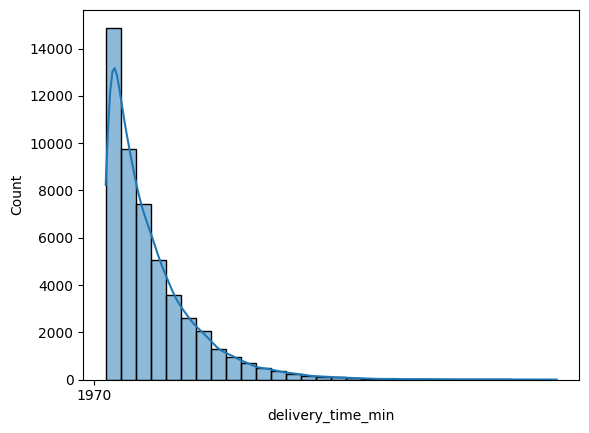

In [42]:
sns.histplot(data=df, x='delivery_time_min', bins=30, kde=True)

<Axes: xlabel='agent_rating', ylabel='Count'>

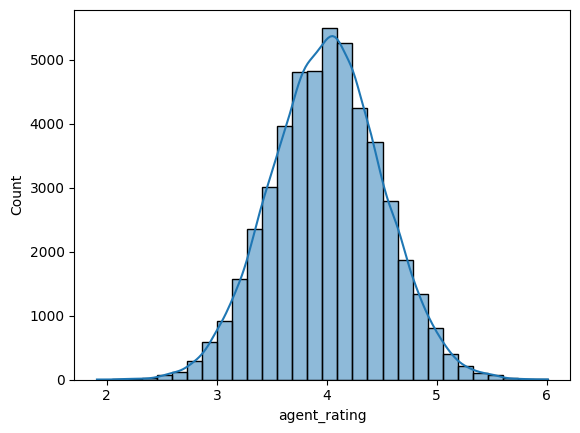

In [43]:
sns.histplot(data=df, x='agent_rating', bins=30, kde=True)

<Axes: xlabel='package_weight_kg'>

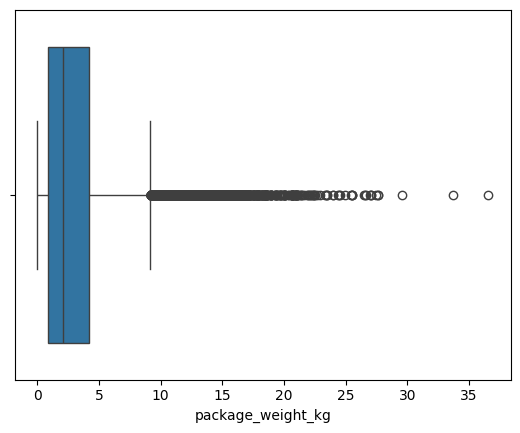

In [44]:
sns.boxplot(data=df, x='package_weight_kg')

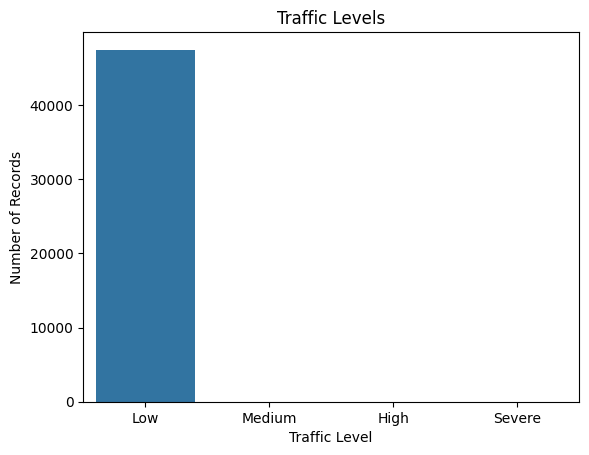

In [51]:
df['traffic_level'] = pd.cut(
    df['traffic_index'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Severe'],
    include_lowest=True
)

sns.countplot(
    data=df,
    x='traffic_level',
    order=['Low', 'Medium', 'High', 'Severe']
)

plt.title('Traffic Levels')
plt.xlabel('Traffic Level')
plt.ylabel('Number of Records')
plt.show()

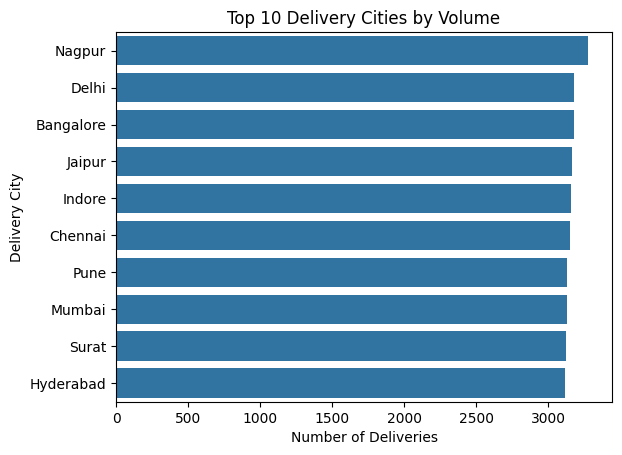

In [60]:
top_10 = df['delivery_city'].value_counts().head(10)

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title('Top 10 Delivery Cities by Volume')
plt.xlabel('Number of Deliveries')
plt.ylabel('Delivery City')
plt.show()

## Advanced Missing Value Treatment

## Outlier Detection & Handling 

## Feature Engineering

## Handling Mixed & Special Variables 

## Encoding Categorical Features 

## Numerical Feature Binning & Discretization 

##  Feature Scaling 

## Feature Transformation & ColumnTransformer Pipeline 

